In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplot
import seaborn as sns
%matplotlib inline

In [ ]:
import pandas as pd

data = {
    "satisfaction_level": [0.38, 0.8, 0.11, None],  # Adjusted to 4 elements
    "last_evaluation": [0.53, 0.86, 0.88, None],   # Adjusted to 4 elements
    "number_project": [2, 5, 7, 5],
    "average_montly_hours": [157, 267, 272, 223],
    "time_spend_company": [3, 6, 4, 5],
    "Work_accident": [0, 0, 0, 0],
    "promotion_last_5years": [0, 0, 0, 0],
    "sales": [1,2,3,4],
    "salary": [10,20,30,40]
}

df = pd.DataFrame(data)
print(df)



   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   267   
2                0.11             0.88               7                   272   
3                 NaN              NaN               5                   223   

   time_spend_company  Work_accident  promotion_last_5years  sales  salary  
0                   3              0                      0      1      10  
1                   6              0                      0      2      20  
2                   4              0                      0      3      30  
3                   5              0                      0      4      40  


In [ ]:
df = df.rename(columns={'satisfaction_level': 'satisfaction',
                        'last_evaluation': 'evaluation',
                        'number_project': 'projectCount',
                        'average_montly_hours': 'averageMonthlyHours',
                        'time_spend_company': 'yearsAtCompany',
                        'Work_accident': 'workAccident',
                        'promotion_last_5years': 'promotion',
                        'sales' : 'department',
                        'left' : 'turnover'
                        })

In [ ]:
df.shape

(4, 9)

In [ ]:
df.dtypes

,0
satisfaction,float64
evaluation,float64
projectCount,int64
averageMonthlyHours,int64
yearsAtCompany,int64
workAccident,int64
promotion,int64
department,int64
salary,int64


In [ ]:
df.describe()

,satisfaction,evaluation,projectCount,averageMonthlyHours,yearsAtCompany,workAccident,promotion,department,salary
count,3.000000,3.000000,4.000000,4.000000,4.000000,4.0,4.0,4.000000,4.000000
mean,0.430000,0.756667,4.750000,229.750000,4.500000,0.0,0.0,2.500000,25.000000
std,0.347707,0.196554,2.061553,53.262714,1.290994,0.0,0.0,1.290994,12.909944
min,0.110000,0.530000,2.000000,157.000000,3.000000,0.0,0.0,1.000000,10.000000
25%,0.245000,0.695000,4.250000,206.500000,3.750000,0.0,0.0,1.750000,17.500000
50%,0.380000,0.860000,5.000000,245.000000,4.500000,0.0,0.0,2.500000,25.000000
75%,0.590000,0.870000,5.500000,268.250000,5.250000,0.0,0.0,3.250000,32.500000
max,0.800000,0.880000,7.000000,272.000000,6.000000,0.0,0.0,4.000000,40.000000


In [ ]:
turnover_rate = df.averageMonthlyHours.value_counts() / 4
turnover_rate

,count
averageMonthlyHours,
157,0.25
267,0.25
272,0.25
223,0.25


AttributeError: module 'seaborn' has no attribute 'plt'

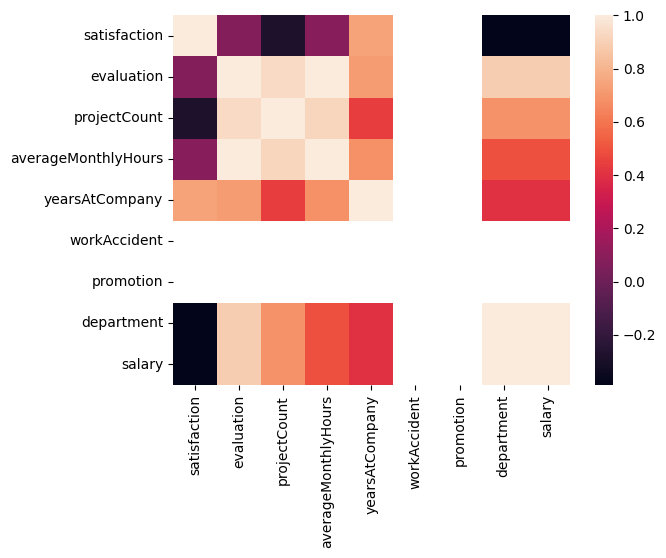

In [ ]:
corr = df.corr()
corr = (corr)
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)
sns.plt.title('Heatmap of Correlation Matrix');
corr

In [ ]:
import pandas as pd

data = {

                  'satisfaction': [0.38, 0.8, 0.11, 0.90],
                  'turnover': [10,20,30,40],
                  "salary": [1000,2000,3000,3500]

}

df = pd.DataFrame(data)
print(df)


emp_population_satisfaction = df['satisfaction'].mean()
emp_turnover_satisfaction = df[df['turnover']==1]['satisfaction'].mean()

print('The mean for the employee population is: ' + str(emp_population_satisfaction) )
print('The mean for the employees that had a turnover is: ' + str(emp_turnover_satisfaction) )

   satisfaction  turnover  salary
0          0.38        10    1000
1          0.80        20    2000
2          0.11        30    3000
3          0.90        40    3500
The mean for the employee population is: 0.5475000000000001
The mean for the employees that had a turnover is: nan


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import scipy.stats as stats
stats.ttest_1samp(a=  df[df['turnover']==1]['satisfaction'], # Sample of Employee satisfaction who had a Turnover
                  popmean = emp_population_satisfaction)

<ipython-input-25-5ff1a5b4759f>:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.ttest_1samp(a=  df[df['turnover']==1]['satisfaction'], # Sample of Employee satisfaction who had a Turnover


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [ ]:
degree_freedom = len(df[df['turnover']==1])

LQ = stats.t.ppf(0.025,degree_freedom)  # Left Quartile

RQ = stats.t.ppf(0.975,degree_freedom)  # Right Quartile

print ('The t-distribution left quartile range is: ' + str(LQ))
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="white")
print ('The t-distribution right quartile range is: ' + str(RQ))

The t-distribution left quartile range is: nan
The t-distribution right quartile range is: nan


   satisfaction  turnover  salary  evaluation  averageMonthlyHours
0          1.38        10    1000        0.53                  157
1          4.80        20    2000        0.86                  267
2          5.11        30    3000        0.88                  272
3          8.90        40    3500        2.00                  223
4         11.00        50    5000        4.00                  700


/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:2125: UserWarning: `displot` is a figure-level function and does not accept the ax= parameter. You may wish to try histplot.
  warnings.warn(msg, UserWarning)


AttributeError: 'FacetGrid' object has no attribute 'set_title'

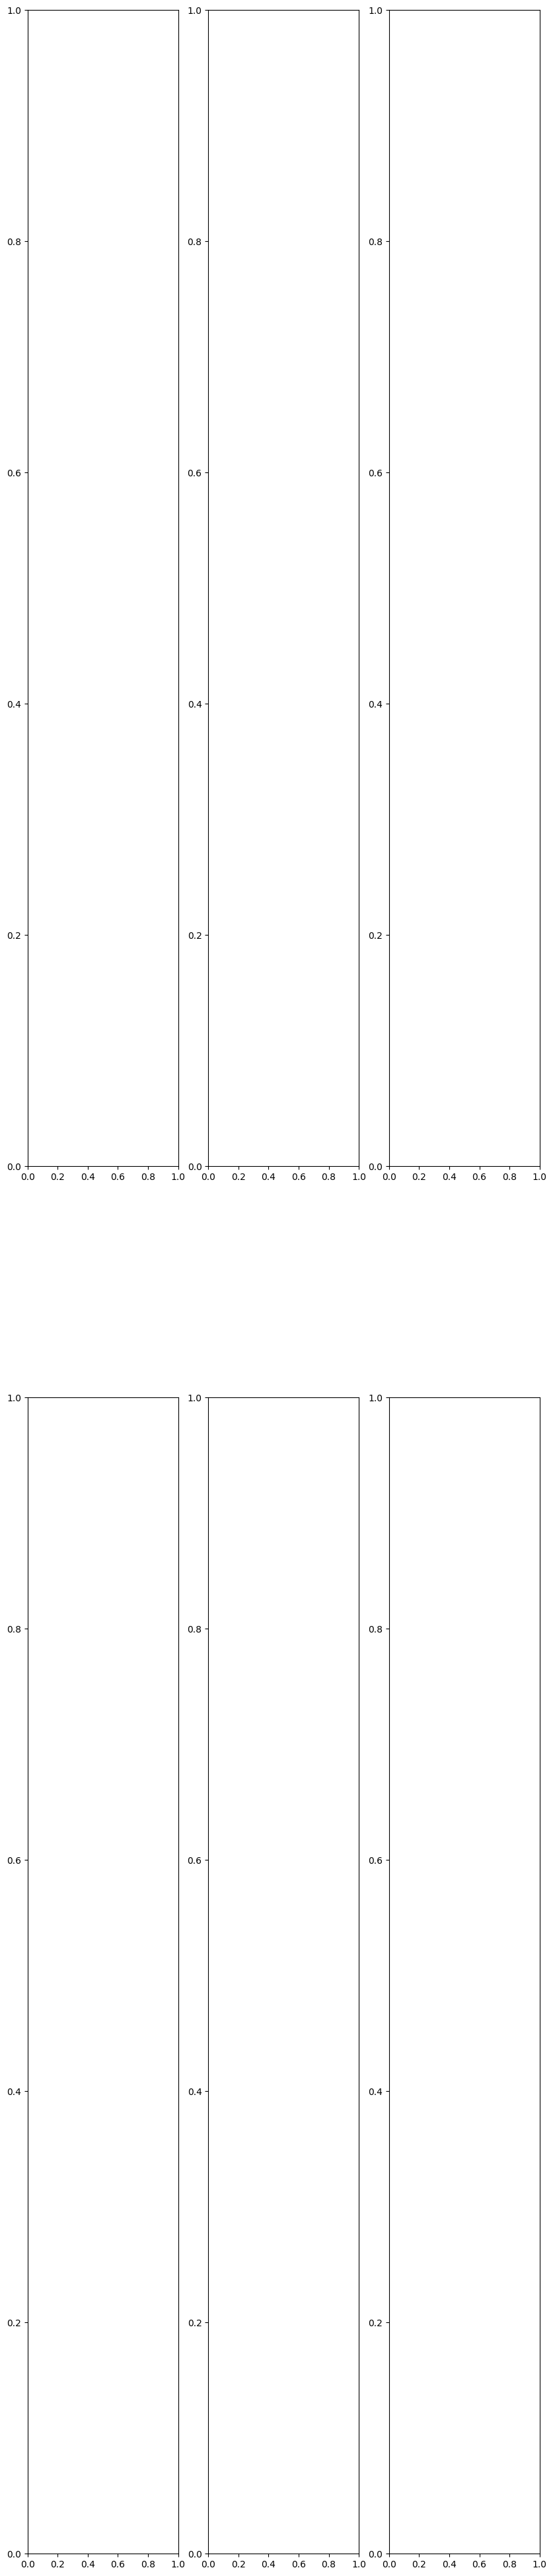

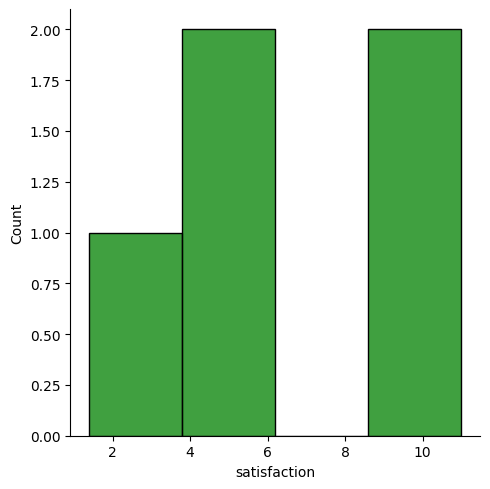

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns;


data = {

                  'satisfaction': [1.38, 4.8, 5.11, 8.90, 11.00],
                  'turnover': [10,20,30,40,50],
                  "salary": [1000,2000,3000,3500,5000],
                  "evaluation": [0.53, 0.86, 0.88, 2.00, 4.00],
                  "averageMonthlyHours": [157, 267, 272, 223,700]

}

df = pd.DataFrame(data)
print(df)

f, axes = plt.subplots(ncols=3, nrows=2, figsize=(10, 50))
# Graph Employee Satisfaction
sns.displot(df.satisfaction, kde=False, color="g", ax=axes[0]).set_title('Employee Satisfaction Distribution')
axes[0].set_ylabel('Employee Count')

# Graph Employee Evaluation
sns.displot(df.evaluation, kde=False, color="r", ax=axes[1]).set_title('Employee Evaluation Distribution')
axes[1].set_ylabel('Employee Count')

# Graph Employee Average Monthly Hours
sns.displot(df.averageMonthlyHours, kde=False, color="b", ax=axes[2]).set_title('Employee Average Monthly Hours Distribution')
axes[2].set_ylabel('Employee Count')

   satisfaction  turnover  salary
0          1.38        10    1000
1          4.80        20    2000
2          5.11        30    3000
3          8.90        40    3500
4         11.00        50    5000


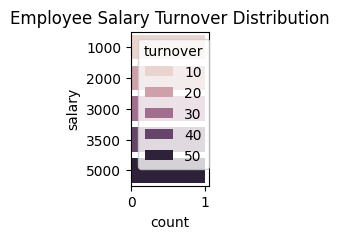

In [ ]:
data = {

                  'satisfaction': [1.38, 4.8, 5.11, 8.90, 11.00],
                  'turnover': [10,20,30,40,50],
                  "salary": [1000,2000,3000,3500,5000]

}

df = pd.DataFrame(data)
print(df)

f, ax = plt.subplots(figsize=(1, 2))
sns.countplot(y="salary", hue='turnover', data=df).set_title('Employee Salary Turnover Distribution');

  department
0         IT
1         HR
2        DEF
3  Marketing
4    Finance
5  Computers
6   Engineer
7      Admin
8        ABC
9        XYZ


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

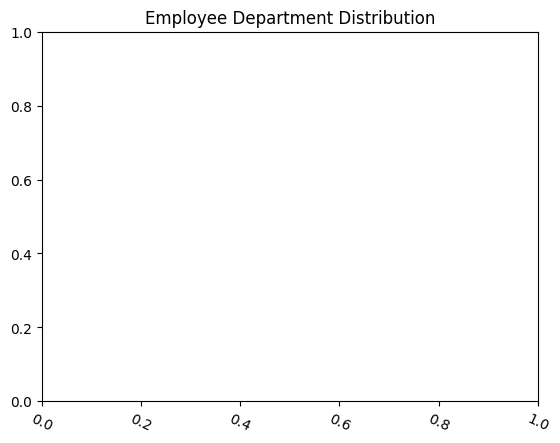

In [ ]:
from re import X
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data ={
    'department': ['IT','HR','DEF','Marketing','Finance','Computers','Engineer','Admin','ABC','XYZ'] }



df = pd.DataFrame(data)
print(df)

color_types = ['#78C850','#F08030','#6890F0','#A8B820','#A8A878','#A040A0','#F8D030',
                '#E0C068','#EE99AC','#C03028','#F85888','#B8A038','#705898','#98D8D8','#7038F8']

# Count Plot (a.k.a. Bar Plot)
sns.countplot(X='department', data=df, palette=color_types).set_title('Employee Department Distribution');

# Rotate x-labels
plt.xticks(rotation=-25)






In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import RobustScaler

data ={
    'department': ['IT','HR','DEF','Marketing','Finance','Computers','Engineer','Admin','ABC','XYZ'],
      'salary': [1000,2000,3000,4000,5000,10000,20000,30000,40000,50000],
      'turnover': [10000,20000,30000,40000,50000,70000,90000,25000,3000,4000]

    }


df = pd.DataFrame(data)
print(df)

# Create dummy variables for the 'department' and 'salary' features, since they are categorical
department = pd.get_dummies(data=df['department'],drop_first=True,prefix='dep') #drop first column to avoid dummy trap
salary = pd.get_dummies(data=df['salary'],drop_first=True,prefix='sal')
df.drop(['department','salary'],axis=1,inplace=True)
df = pd.concat([df,department,salary],axis=1)



  department  salary  turnover
0         IT    1000     10000
1         HR    2000     20000
2        DEF    3000     30000
3  Marketing    4000     40000
4    Finance    5000     50000
5  Computers   10000     70000
6   Engineer   20000     90000
7      Admin   30000     25000
8        ABC   40000      3000
9        XYZ   50000      4000


In [ ]:
def base_rate_model(X) :
    y = np.zeros(X.shape[0])
    return y

   sales  salary  number_project  turnover
0      1      10               2        10
1      2      20               5        20
2      3      30               7        30
3      4      40               5        40


<ipython-input-28-8e40b223c6ae>:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:salmon'` for the same effect.

  sns.countplot(x='sales', hue='salary', data=df, color="salmon")


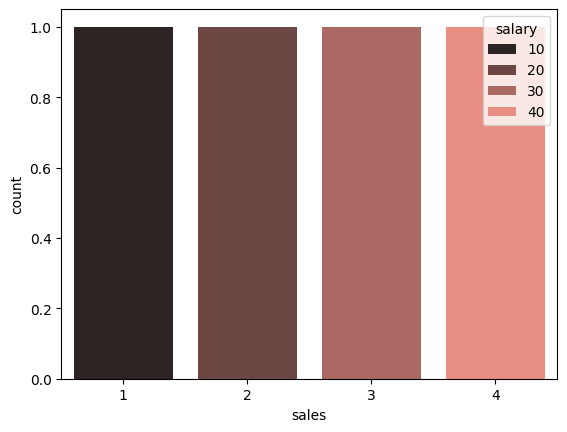

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as matplot
import pandas as pd

data = {

        "sales": [1,2,3,4],
    "salary": [10,20,30,40],
        "number_project": [2, 5, 7, 5],
        'turnover': [10,20,30,40]

}
df=pd.DataFrame(data)
print(df)

# Load the Titanic dataset from seaborn library


sns.countplot(x='sales', hue='salary', data=df, color="salmon")

plt.show()

[Text(0, 0.5, 'Percent')]

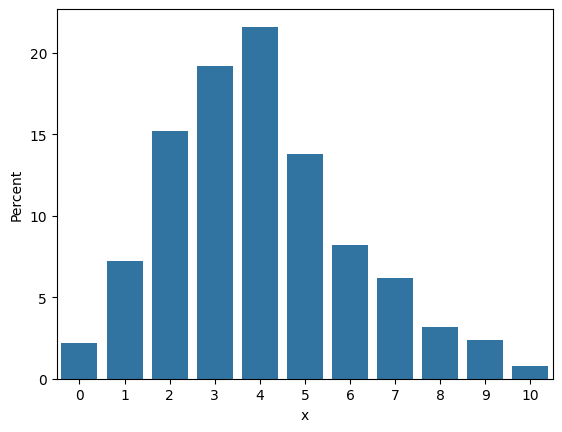

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.DataFrame(dict(x=np.random.poisson(4, 500)))
ax = sns.barplot(x="x", y="x", data=df, estimator=lambda x: len(x) / len(df) * 100)
ax.set(ylabel="Percent")

   sales  last_evaluation  turnover  evaluation
0      1             0.53      1000       15300
1      2             0.86      2000       28600
2      3             0.88      3000       38800
3      4              NaN      4000       40000
4      5             1.00      5000       60000


<ipython-input-6-714c5f853b80>:21: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax=sns.kdeplot(df.loc[(df['turnover'] == 0),'evaluation'] , color='b',shade=True,label='no turnover')
<ipython-input-6-714c5f853b80>:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax=sns.kdeplot(df.loc[(df['turnover'] == 1),'evaluation'] , color='r',shade=True, label='turnover')


Text(0.5, 1.0, 'Employee Evaluation Distribution - Turnover V.S. No Turnover')

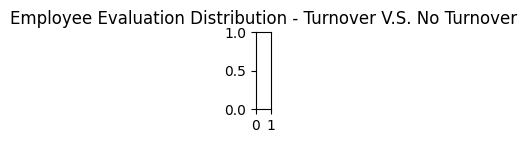

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as matplot
%matplotlib inline


data={

       'sales': [1,2,3,4,5],
'last_evaluation': [0.53, 0.86, 0.88, None,1.00],
      'turnover': [1000,2000,3000,4000,5000],
     'evaluation': [15300, 28600, 38800, 40000,60000]
}

df=pd.DataFrame(data)
print(df)

fig = plt.figure(figsize=(0.2,1.00),)
ax=sns.kdeplot(df.loc[(df['turnover'] == 0),'evaluation'] , color='b',shade=True,label='no turnover')
ax=sns.kdeplot(df.loc[(df['turnover'] == 1),'evaluation'] , color='r',shade=True, label='turnover')
plt.title('Employee Evaluation Distribution - Turnover V.S. No Turnover')

   projectCount  averageMonthlyHours  turnover
0             2                  157      1000
1             5                  267      2000
2             7                  272      3000
3             5                  223      4000


<Axes: xlabel='projectCount', ylabel='averageMonthlyHours'>

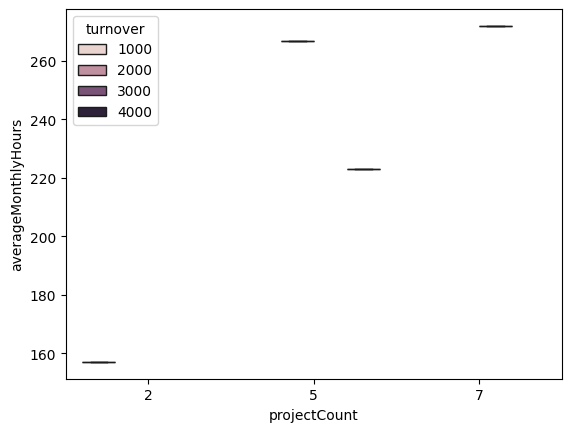

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as matplot
%matplotlib inline

data={
'projectCount': [2,5,7,5],
'averageMonthlyHours': [157, 267, 272, 223],
'turnover': [1000,2000,3000,4000]
       }

df=pd.DataFrame(data)
print(df)

sns.boxplot(x="projectCount", y="averageMonthlyHours", hue="turnover", data=df)




In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import RobustScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as matplot
%matplotlib inline


# Create dummy variables for the 'department' and 'salary' features, since they are categorical
data ={

    'department': ['HR','DEF','Marketing','Finance'],
      'salary': [2000,3000,4000,5000] }

df=pd.DataFrame(data)
print(df)

department = pd.get_dummies(data=df['department'],drop_first=True,prefix='dep') #drop first column to avoid dummy trap
salary = pd.get_dummies(data=df['salary'],drop_first=True,prefix='sal')
df.drop(['department','salary'],axis=1,inplace=True)
df = pd.concat([df,department,salary],axis=1)

  department  salary
0         HR    2000
1        DEF    3000
2  Marketing    4000
3    Finance    5000


In [43]:
def base_rate_model(X) :
    y = np.zeros(X.shape[0])
    return y

In [85]:
from sklearn.preprocessing import RobustScaler

data={

'turnover': [1000,2000,3000,4000],
 'X': [2,3,4,5],
 'y': [0.1,0.2,0.3,0.4]

}
df=pd.DataFrame(data)
print(df)

target_name = 'turnover'
X = df.drop('turnover', axis=1)


# Create a RobustScaler object
robust_scaler = RobustScaler()

# Fit and transform the data
X_robust_scaled = robust_scaler.fit_transform(X)
y = df[target_name]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)



   turnover  X    y
0      1000  2  0.1
1      2000  3  0.2
2      3000  4  0.3
3      4000  5  0.4


In [87]:

import numpy as np

y_base_rate = base_rate_model(X_test)
from sklearn.metrics import accuracy_score
print ("Base rate accuracy is %2.2f" % accuracy_score(y_test, y_base_rate))

Base rate accuracy is 0.00


In [88]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty='l2', C=1)

model.fit(X_train, y_train)
print ("Logistic accuracy is %2.2f" % accuracy_score(y_test, model.predict(X_test)))

Logistic accuracy is 0.00


In [102]:
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
import numpy as np

kfold = model_selection.KFold(n_splits=2, random_state=None)
modelCV = LogisticRegression(class_weight = "balanced")
scoring = 'roc_auc'
results = model_selection.cross_val_score(modelCV, X_train, y_train, cv=kfold, scoring=scoring)
print("AUC: %.3f (%.3f)" % (results.mean(), results.std()))

AUC: nan (nan)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 2.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *arg